# Fine-Tuning TimesFM 2.5 on Custom Time Series Data

End-to-end pipeline: load data → LoRA fine-tune TimesFM 2.5 → evaluate → forecast

Supports:
- **NetCDF** climate/weather data (xarray)
- **CSV** tabular time series
- **Synthetic** data for quick testing

Uses HuggingFace Transformers + PEFT (LoRA) for parameter-efficient fine-tuning.

In [1]:
!pip install -q transformers accelerate peft torch numpy pandas matplotlib scikit-learn xarray h5netcdf netCDF4 "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import TimesFm2_5ModelForPrediction
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"Memory: {total / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 1. Configuration

In [3]:
class Config:
    # Data source: "synthetic", "csv", or "netcdf"
    data_source = "synthetic"

    # CSV settings
    csv_path = "your_data.csv"
    csv_value_columns = None  # None = all numeric columns; or list like ["col1", "col2"]

    # NetCDF settings (similar to your hadgem_aviso.nc workflow)
    netcdf_path = "your_data.nc"
    netcdf_variable = "DSL"

    # Model
    model_name = "google/timesfm-2.5-200m-transformers"
    context_len = 128       # must be multiple of 32
    horizon_len = 32        # forecast horizon

    # LoRA
    lora_r = 4
    lora_alpha = 8
    lora_dropout = 0.05

    # Training
    batch_size = 32
    num_epochs = 10
    learning_rate = 1e-4
    weight_decay = 0.01
    max_grad_norm = 1.0
    num_train_samples = 5000
    num_val_samples = 1000

    # Split ratios
    train_ratio = 0.8
    val_ratio = 0.1
    test_ratio = 0.1

    # Output
    save_dir = "timesfm_finetuned"

cfg = Config()

## 2. Data Loading

Each loader returns `series_list`: a list of 1-D numpy arrays, one per time series.

In [4]:
def load_synthetic_data(n_series=500, min_len=300, max_len=600, seed=42):
    """Mixed synthetic time series: trends, seasonality, noise, regime changes."""
    rng = np.random.default_rng(seed)
    series_list = []
    for i in range(n_series):
        length = rng.integers(min_len, max_len + 1)
        t = np.arange(length, dtype=np.float32)

        trend = rng.uniform(-0.02, 0.02) * t
        period = rng.choice([12, 24, 52, 96, 168])
        seasonal = rng.uniform(0.5, 3.0) * np.sin(2 * np.pi * t / period)
        noise = rng.normal(0, rng.uniform(0.1, 1.0), length)

        if rng.random() > 0.7:
            cp = rng.integers(length // 4, 3 * length // 4)
            trend[cp:] += rng.uniform(-3, 3)

        series = (trend + seasonal + noise).astype(np.float32)
        series_list.append(series)
    return series_list


def load_csv_data(path, value_columns=None):
    """Load CSV where each numeric column is a separate time series."""
    df = pd.read_csv(path)
    if value_columns is None:
        value_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    return [df[col].dropna().values.astype(np.float32) for col in value_columns]


def load_netcdf_data(path, variable, max_spatial=10000, seed=42):
    """Load NetCDF: reshape (time, lat, lon) → list of per-pixel time series."""
    import xarray as xr
    ds = xr.open_dataset(path, engine="h5netcdf")
    data = ds[variable].values  # (time, lat, lon) or (time, ...)

    # Handle ensemble dimension if present
    if data.ndim == 4:
        data = data.mean(axis=1)

    n_time = data.shape[0]
    data_2d = data.reshape(n_time, -1)  # (time, n_pixels)
    n_pixels = data_2d.shape[1]

    # Subsample pixels if too many
    rng = np.random.default_rng(seed)
    if n_pixels > max_spatial:
        idx = rng.choice(n_pixels, max_spatial, replace=False)
        data_2d = data_2d[:, idx]
        n_pixels = max_spatial

    series_list = []
    for i in range(n_pixels):
        ts = data_2d[:, i].astype(np.float32)
        ts = np.nan_to_num(ts, nan=0.0)
        series_list.append(ts)
    return series_list

In [5]:
if cfg.data_source == "synthetic":
    all_series = load_synthetic_data()
elif cfg.data_source == "csv":
    all_series = load_csv_data(cfg.csv_path, cfg.csv_value_columns)
elif cfg.data_source == "netcdf":
    all_series = load_netcdf_data(cfg.netcdf_path, cfg.netcdf_variable)
else:
    raise ValueError(f"Unknown data_source: {cfg.data_source}")

print(f"Loaded {len(all_series)} time series")
print(f"Lengths: min={min(len(s) for s in all_series)}, max={max(len(s) for s in all_series)}, "
      f"median={int(np.median([len(s) for s in all_series]))}")

Loaded 500 time series
Lengths: min=300, max=600, median=452


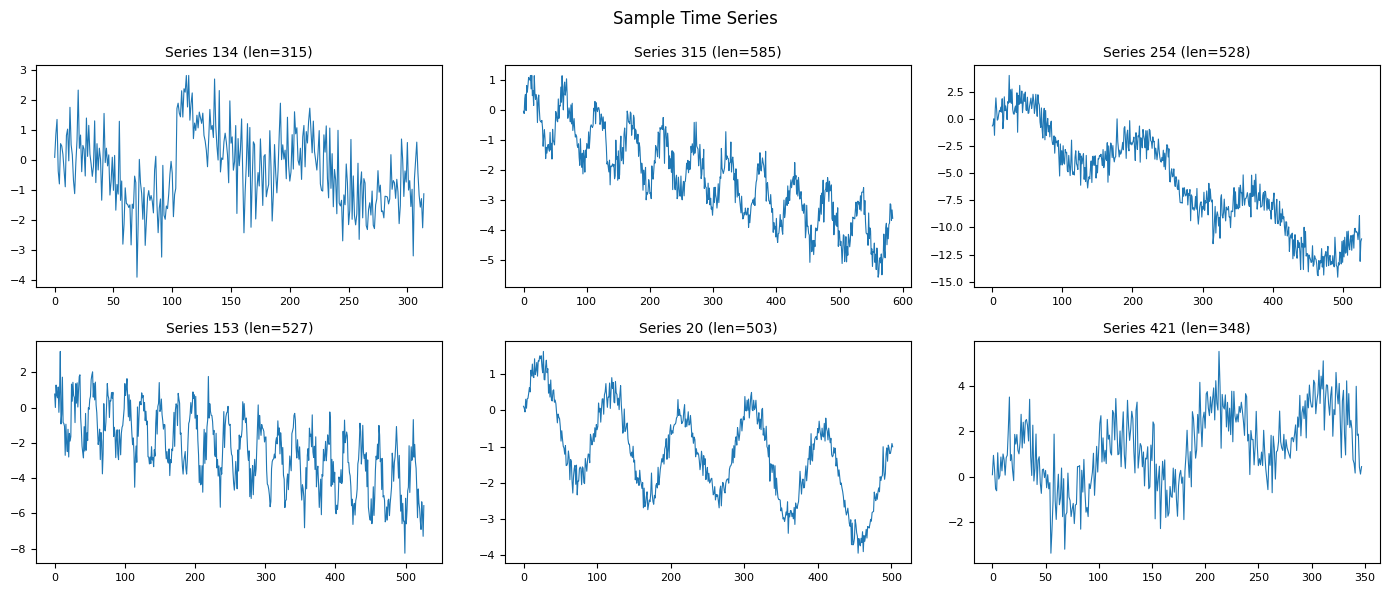

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(all_series), min(6, len(all_series)), replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.plot(all_series[idx], linewidth=0.8)
    ax.set_title(f"Series {idx} (len={len(all_series[idx])})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Sample Time Series", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Train / Val / Test Split

In [7]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(all_series))
n_train = int(len(all_series) * cfg.train_ratio)
n_val = int(len(all_series) * cfg.val_ratio)

train_series = [all_series[i] for i in indices[:n_train]]
val_series = [all_series[i] for i in indices[n_train:n_train + n_val]]
test_series = [all_series[i] for i in indices[n_train + n_val:]]

# Filter out series too short for context + horizon
min_len = cfg.context_len + cfg.horizon_len
train_series = [s for s in train_series if len(s) >= min_len]
val_series = [s for s in val_series if len(s) >= min_len]
test_series = [s for s in test_series if len(s) >= min_len]

print(f"Train: {len(train_series)}, Val: {len(val_series)}, Test: {len(test_series)}")

Train: 400, Val: 50, Test: 50


## 4. Dataset & DataLoader

In [8]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, series_list, context_len, horizon_len, num_samples, seed=42):
        self.series_list = series_list
        self.context_len = context_len
        self.horizon_len = horizon_len
        self.samples = []
        rng = np.random.default_rng(seed)
        min_len = context_len + horizon_len
        valid = [i for i, s in enumerate(series_list) if len(s) >= min_len]
        for _ in range(num_samples):
            idx = rng.choice(valid)
            max_start = len(series_list[idx]) - min_len
            start = rng.integers(0, max_start + 1)
            self.samples.append((idx, start))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        idx, start = self.samples[i]
        series = self.series_list[idx]
        context = torch.tensor(series[start:start + self.context_len], dtype=torch.float32)
        target = torch.tensor(series[start + self.context_len:start + self.context_len + self.horizon_len],
                              dtype=torch.float32)
        return context, target


train_ds = TimeSeriesWindowDataset(train_series, cfg.context_len, cfg.horizon_len,
                                   cfg.num_train_samples, seed=42)
val_ds = TimeSeriesWindowDataset(val_series, cfg.context_len, cfg.horizon_len,
                                 cfg.num_val_samples, seed=123)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 156, Val batches: 32


## 5. Load TimesFM + Apply LoRA

In [9]:
model = TimesFm2_5ModelForPrediction.from_pretrained(
    cfg.model_name,
    torch_dtype=torch.bfloat16,
    device_map=device,
)
print(f"Base model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Base model parameters: 231,289,280


In [10]:
lora_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    target_modules="all-linear",
    lora_dropout=cfg.lora_dropout,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,382,912 || all params: 232,672,192 || trainable%: 0.5944


## 6. Baseline Evaluation (Before Fine-Tuning)

In [11]:
@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0
    n_batches = 0
    for context, target in dataloader:
        context = context.to(device)
        target = target.to(device)
        outputs = model(past_values=context, future_values=target,
                        forecast_context_len=context.shape[1])
        total_loss += outputs.loss.item()
        preds = outputs.mean_predictions[:, :target.shape[1]]
        all_preds.append(preds.float().cpu().numpy())
        all_targets.append(target.float().cpu().numpy())
        n_batches += 1
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    mse = mean_squared_error(all_targets.flatten(), all_preds.flatten())
    mae = mean_absolute_error(all_targets.flatten(), all_preds.flatten())
    return {"loss": total_loss / n_batches, "mse": mse, "mae": mae,
            "preds": all_preds, "targets": all_targets}


baseline = evaluate(model, val_loader, device)
print(f"Baseline — Loss: {baseline['loss']:.4f}, MSE: {baseline['mse']:.4f}, MAE: {baseline['mae']:.4f}")

Baseline — Loss: 0.6259, MSE: 0.8468, MAE: 0.6392


## 7. Fine-Tuning

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.num_epochs * len(train_loader)
)

train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(cfg.num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_idx, (context, target) in enumerate(train_loader):
        context = context.to(device)
        target = target.to(device)

        outputs = model(
            past_values=context,
            future_values=target,
            forecast_context_len=context.shape[1],
        )
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.max_grad_norm)
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_result = evaluate(model, val_loader, device)
    val_losses.append(val_result["loss"])

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        model.save_pretrained(cfg.save_dir)
        tag = " ← saved"
    else:
        tag = ""

    print(f"Epoch {epoch+1}/{cfg.num_epochs} — "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {val_result['loss']:.4f}, "
          f"Val MSE: {val_result['mse']:.4f}, "
          f"Val MAE: {val_result['mae']:.4f}"
          f"{tag}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1/10 — Train Loss: 0.5656, Val Loss: 0.4134, Val MSE: 0.5390, Val MAE: 0.5221 ← saved
Epoch 2/10 — Train Loss: 0.4802, Val Loss: 0.3963, Val MSE: 0.5134, Val MAE: 0.5091 ← saved
Epoch 3/10 — Train Loss: 0.4518, Val Loss: 0.3893, Val MSE: 0.5048, Val MAE: 0.5047 ← saved
Epoch 4/10 — Train Loss: 0.4320, Val Loss: 0.3910, Val MSE: 0.5079, Val MAE: 0.5055
Epoch 5/10 — Train Loss: 0.4189, Val Loss: 0.3942, Val MSE: 0.5105, Val MAE: 0.5066
Epoch 6/10 — Train Loss: 0.4083, Val Loss: 0.3949, Val MSE: 0.5107, Val MAE: 0.5065
Epoch 7/10 — Train Loss: 0.4007, Val Loss: 0.4006, Val MSE: 0.5232, Val MAE: 0.5106
Epoch 8/10 — Train Loss: 0.3956, Val Loss: 0.4009, Val MSE: 0.5211, Val MAE: 0.5101
Epoch 9/10 — Train Loss: 0.3935, Val Loss: 0.4020, Val MSE: 0.5232, Val MAE: 0.5110
Epoch 10/10 — Train Loss: 0.3925, Val Loss: 0.4026, Val MSE: 0.5233, Val MAE: 0.5111

Best val loss: 0.3893


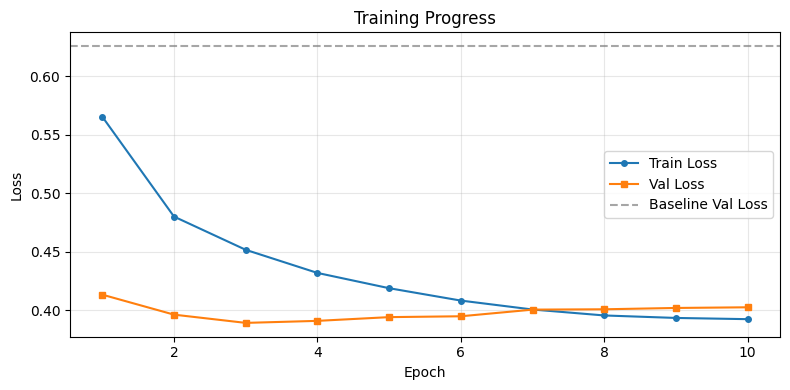

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss", marker="o", markersize=4)
ax.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss", marker="s", markersize=4)
ax.axhline(baseline["loss"], color="gray", linestyle="--", alpha=0.7, label="Baseline Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Load Best Model & Evaluate on Test Set

In [14]:
base_model = TimesFm2_5ModelForPrediction.from_pretrained(
    cfg.model_name,
    torch_dtype=torch.bfloat16,
    device_map=device,
)
ft_model = PeftModel.from_pretrained(base_model, cfg.save_dir)
ft_model.eval()

test_ds = TimeSeriesWindowDataset(test_series, cfg.context_len, cfg.horizon_len,
                                  num_samples=500, seed=999)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

# Evaluate both base and fine-tuned on test set
base_model_eval = TimesFm2_5ModelForPrediction.from_pretrained(
    cfg.model_name,
    torch_dtype=torch.bfloat16,
    device_map=device,
)
base_test = evaluate(base_model_eval, test_loader, device)
ft_test = evaluate(ft_model, test_loader, device)

print(f"{'Metric':<12} {'Base':>10} {'Fine-Tuned':>12} {'Improvement':>14}")
print("-" * 50)
for metric in ["mse", "mae"]:
    b, f = base_test[metric], ft_test[metric]
    imp = (b - f) / b * 100
    print(f"{metric.upper():<12} {b:>10.4f} {f:>12.4f} {imp:>+13.1f}%")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Metric             Base   Fine-Tuned    Improvement
--------------------------------------------------
MSE              1.0016       0.6991         +30.2%
MAE              0.7282       0.6015         +17.4%


## 9. Visualize Forecasts

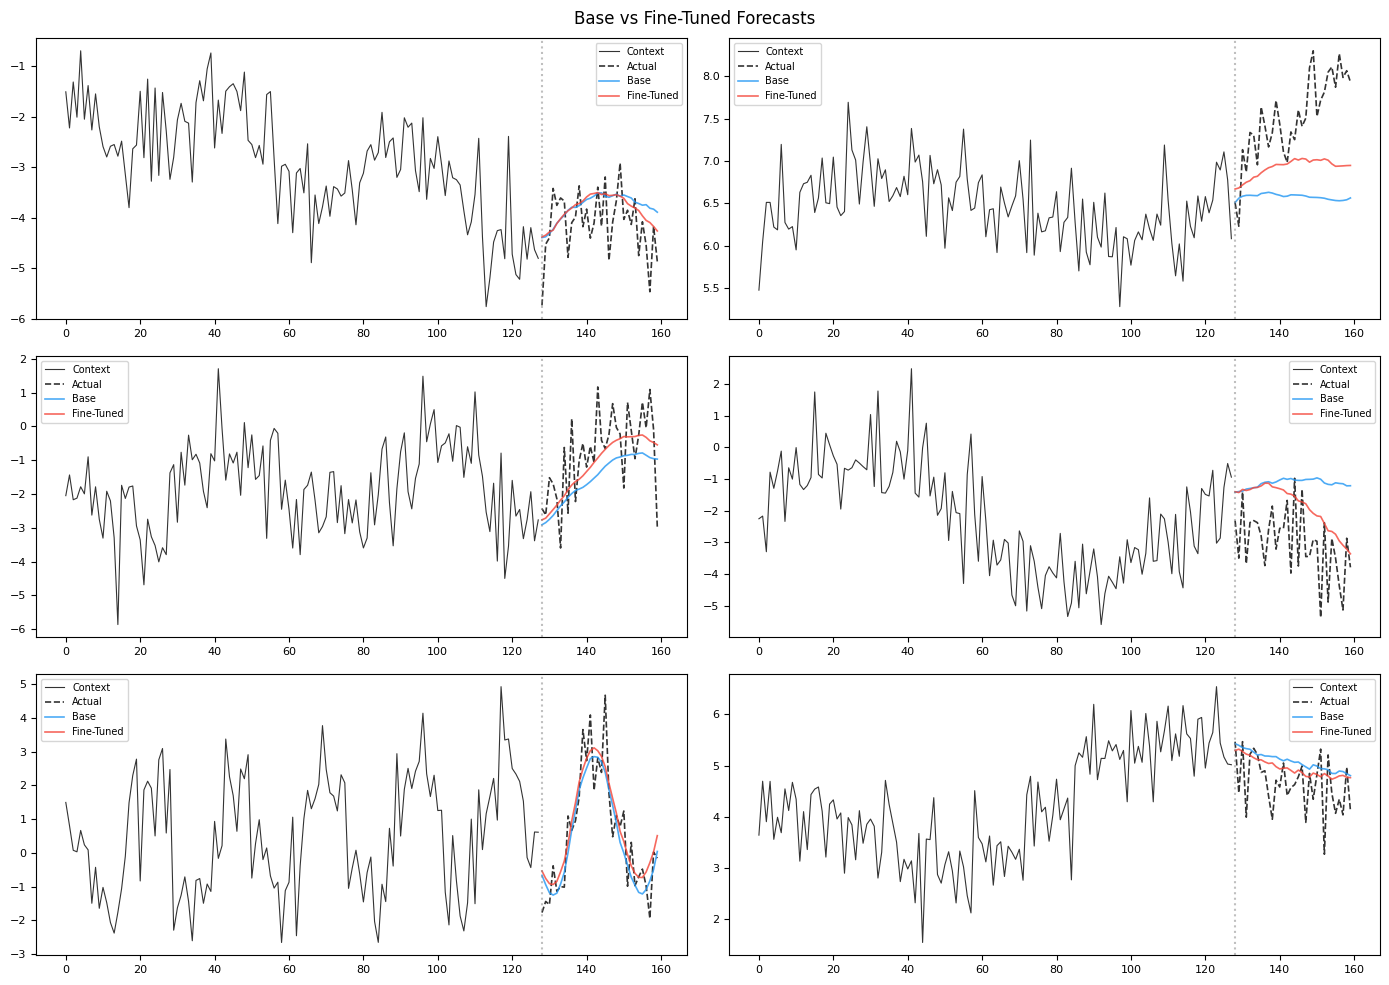

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
rng = np.random.default_rng(7)

for ax in axes.flat:
    idx = rng.integers(0, len(test_series))
    ts = test_series[idx]
    if len(ts) < cfg.context_len + cfg.horizon_len:
        continue
    start = rng.integers(0, len(ts) - cfg.context_len - cfg.horizon_len + 1)
    context = torch.tensor(ts[start:start + cfg.context_len], dtype=torch.float32).unsqueeze(0).to(device)
    actual = ts[start + cfg.context_len:start + cfg.context_len + cfg.horizon_len]

    with torch.no_grad():
        base_out = base_model_eval(past_values=context)
        ft_out = ft_model(past_values=context)
    base_pred = base_out.mean_predictions[0, :cfg.horizon_len].float().cpu().numpy()
    ft_pred = ft_out.mean_predictions[0, :cfg.horizon_len].float().cpu().numpy()

    t_ctx = np.arange(cfg.context_len)
    t_fwd = np.arange(cfg.context_len, cfg.context_len + cfg.horizon_len)

    ax.plot(t_ctx, ts[start:start + cfg.context_len], color="#333", linewidth=0.8, label="Context")
    ax.plot(t_fwd, actual, color="#333", linewidth=1.2, linestyle="--", label="Actual")
    ax.plot(t_fwd, base_pred, color="#2196F3", linewidth=1.2, alpha=0.8, label="Base")
    ax.plot(t_fwd, ft_pred, color="#F44336", linewidth=1.2, alpha=0.8, label="Fine-Tuned")
    ax.axvline(cfg.context_len, color="gray", linestyle=":", alpha=0.5)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.suptitle("Base vs Fine-Tuned Forecasts", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Inference on New Data

Use the fine-tuned model to forecast arbitrary time series.

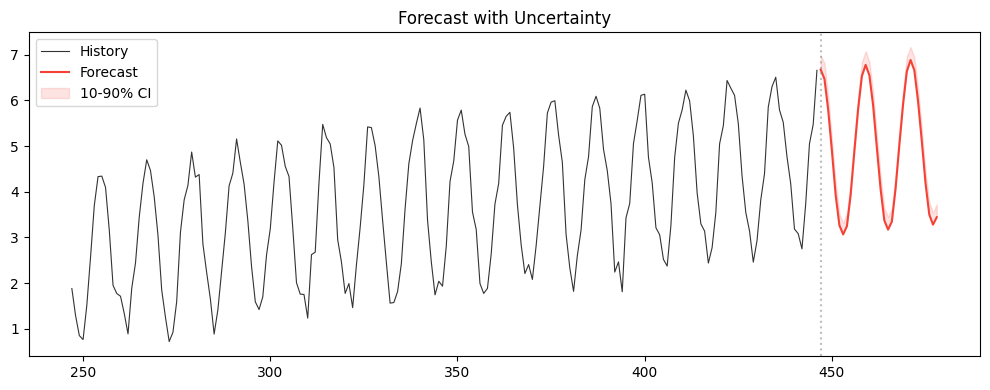

In [16]:
def forecast(model, time_series, context_len, horizon_len, device="cpu"):
    """Forecast the next `horizon_len` steps given the last `context_len` values.
    Returns point forecast and quantile predictions."""
    ts = np.asarray(time_series, dtype=np.float32)
    context = ts[-context_len:]
    context_tensor = torch.tensor(context, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(past_values=context_tensor)

    point = outputs.mean_predictions[0, :horizon_len].float().cpu().numpy()
    quantiles = None
    if outputs.full_predictions is not None:
        quantiles = outputs.full_predictions[0, :horizon_len].float().cpu().numpy()
    return point, quantiles


# Example
sample_ts = test_series[0]
point_pred, quantile_pred = forecast(ft_model, sample_ts, cfg.context_len, cfg.horizon_len, device)

fig, ax = plt.subplots(figsize=(10, 4))
t_hist = np.arange(len(sample_ts))
t_fwd = np.arange(len(sample_ts), len(sample_ts) + cfg.horizon_len)

ax.plot(t_hist[-200:], sample_ts[-200:], color="#333", linewidth=0.8, label="History")
ax.plot(t_fwd, point_pred, color="#F44336", linewidth=1.5, label="Forecast")
if quantile_pred is not None and quantile_pred.ndim == 2:
    ax.fill_between(t_fwd, quantile_pred[:, 0], quantile_pred[:, -1],
                    alpha=0.15, color="#F44336", label="10-90% CI")
ax.axvline(len(sample_ts), color="gray", linestyle=":", alpha=0.5)
ax.legend()
ax.set_title("Forecast with Uncertainty")
plt.tight_layout()
plt.show()

## 11. Using Your Own Data

To fine-tune on your own data, change the `Config` at the top:

**CSV data:**
```python
cfg.data_source = "csv"
cfg.csv_path = "/path/to/your/data.csv"
cfg.csv_value_columns = ["temperature", "pressure"]  # or None for all numeric columns
```

**NetCDF climate data:**
```python
cfg.data_source = "netcdf"
cfg.netcdf_path = "/path/to/hadgem_aviso.nc"
cfg.netcdf_variable = "DSL"
```

**Key tuning knobs:**
- `context_len`: must be a multiple of 32. Longer = more context but more memory. Try 128, 256, 512.
- `horizon_len`: forecast horizon. Start small (16-32) and increase.
- `lora_r`: LoRA rank. Higher = more capacity but slower. 4 is a good default, try 8 or 16 for complex data.
- `num_epochs`: 5-20 is typical. Watch val loss for overfitting.
- `learning_rate`: 1e-4 is safe. For small datasets try 5e-5.

**Note:** TimesFM handles normalization internally (RevIN), so do NOT normalize your data before passing it in.